# Fin Brains — wykrywanie oszustw w transakcjach finansowych
Notebook projektowy

**Zespół:**  
- Marceli Orzechowski  
- Wojciech Wieloch  
- Edyta Obuchiewicz  
- Agnieszka Rosner  

**Dataset:** [Financial Transaction for Fraud Detection Research — Kaggle](https://www.kaggle.com/datasets/ziya07/financial-transaction-for-fraud-detection-research)

**JIRA Zespołu:** [DS24G3](https://jira.is-academy.pl/secure/RapidBoard.jspa?rapidView=811&projectKey=DS24G3&view=planning&selectedIssue=DS24G3-1&issueLimit=100)


## 1. Cel projektu

Celem projektu jest analiza danych dotyczących transakcji finansowych sklepu internetowego oraz identyfikacja cech charakterystycznych dla fraudów. Na podstawie przeprowadzonej analizy zostaną opracowane i porównane modele uczenia maszynowego służące do wykrywania fraudów. Projekt ma na celu ocenę, na ile informacje o transakcji (m.in. kwota, czas, typ urządzenia, lokalizacja klienta oraz kategoria zakupu) pozwalają skutecznie odróżnić transakcje fraudowe od prawidłowych oraz wspierać ograniczanie strat finansowych i zwiększanie bezpieczeństwa klientów.

## Pytanie projektowe

Czy na podstawie dostępnych danych o transakcjach finansowych można zbudować model, który będzie skutecznie wykrywał transakcje fraudowe, przy jednoczesnym ograniczeniu liczby niewykrytych oszustw oraz fałszywych alarmów?

## Kryteria sukcesu projektu

* przeprowadzenie eksploracyjnej analizy danych i identyfikacja cech powiązanych z występowaniem fraudów,
* zbudowanie i porównanie kilku modeli klasyfikacyjnych,
* ocena modeli z wykorzystaniem metryk odpowiednich dla niezbalansowanych danych (precision, recall oraz F1-score),
* wskazanie modelu najlepiej równoważącego skuteczność wykrywania fraudów i liczbę fałszywych alarmów,
* przedstawienie rekomendacji biznesowych wynikających z analizy danych i uzyskanych modeli.


## 2. Wybrany zbiór danych

**Nazwa zbioru:** Financial Transaction for Fraud Detection Research  
**Źródło:** Kaggle  
**Link:** [otwórz stronę datasetu](https://www.kaggle.com/datasets/ziya07/financial-transaction-for-fraud-detection-research)

### Do uzupełnienia
- Krótki opis zbioru danych:
- Liczba rekordów: 10000
- Liczba kolumn: 10
- Kolumna oznaczająca fraud:
- Uzasadnienie wyboru datasetu:


## 3. Interesariusze projektu

***Dział Ryzyka***
Cel: zmniejszenie liczby niewykrytych oszustw 

***Dział Security***
Cel: możliwość szybkiej reakcji na podejrzane działania

***Dział Finansowy***
Cel: ograniczenie strat finansowych. 

***Klienci tego sklepu internetowego***
Cel: bezproblemowy zakup


## 4. Potrzeby interesariuszy

***Dział Ryzyka***
Potrzeby: wykrywanie transakcji o wysokim ryzyku, identyfikacja nietypowych zachowań klientów, znane wzorce fraudów. 

***Dział Security***
Potrzeby: możliwość oznaczenia podejrzanych transakcji w czasie rzeczywistym.

***Dział Finansowy***
Potrzeby: blokowanie najbardziej ryzykownych transakcji, raportowanie liczby wykrytych fraudów, zmniejszenie kosztów reklamacji.

***Klienci tego sklepu internetowego***
Potrzeby: ochrona przed nieautoryzowanymi transakcjami z ich konta, brak błędnego blokowania prawidłowych operacji.

### Pytania pomocnicze
- Co jest większym problemem: niewykryty fraud czy fałszywy alarm?
- Czy model miałby blokować transakcje, czy jedynie kierować je do sprawdzenia?



## 5. Preprocessing danych

**Cel sekcji:** przygotowanie danych do dalszej analizy i modelowania.










Device_type_desktop = FALSE, FALSE,


Merchant_category_grocery = FALSE, FALSE




In [1]:
import pandas as pd

# Wczytanie danych
df = pd.read_csv("financial_fraud_dataset.csv")

# Zmiana nazw podstawowych kolumn
df = df.rename(columns={
    "transaction_id": "Transaction_id",
    "customer_id": "Customer_id",
    "amount": "Bank_Amount",
    "timestamp": "Timestamp",
    "customer_age": "Customer_age",
    "previous_transactions": "Previous_transaction",
    "is_fraud": "Is_fraud"
})

# Konwersja daty
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Wyciągnięcie cech z daty
df["Month"] = df["Timestamp"].dt.month
df["Day"] = df["Timestamp"].dt.day
df["Week_day"] = df["Timestamp"].dt.dayofweek
df["Hours"] = df["Timestamp"].dt.hour
df["Minutes"] = df["Timestamp"].dt.minute
df["Seconds"] = df["Timestamp"].dt.second


# One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=[
        "device_type",
        "merchant_category",
        "customer_location"
    ],
    dtype=bool
)

# Zmiana nazw kolumn lokalizacji
df = df.rename(columns={
    col: col.replace("customer_location_", "Cus_loc_")
    for col in df.columns
    if col.startswith("customer_location_")
})

# Zmiana nazw kolumn urządzeń
df = df.rename(columns={
    "device_type_mobile": "Device_type_mobile",
    "device_type_tablet": "Device_type_tablet"
})

# Zmiana nazw merchant category
df = df.rename(columns={
    col: col.replace("merchant_category_", "cat_")
    for col in df.columns
    if col.startswith("merchant_category_")
})

# Przeniesienie klasy na koniec
is_fraud = df.pop("Is_fraud")
df["Is_fraud"] = is_fraud



df.to_csv("preproccesing_base_final_final.csv", index=False)

FileNotFoundError: [Errno 2] No such file or directory: 'financial_fraud_dataset.csv'

# 6. Exploratory Data Analysis (EDA)

### Cel analizy

Celem analizy jest eksploracja przygotowanego zbioru danych dotyczącego transakcji finansowych, poznanie charakterystyki transakcji prawidłowych i fraudowych, identyfikacja zależności pomiędzy zmiennymi oraz sformułowanie wniosków biznesowych, które mogą wspierać opracowanie modeli wykrywania oszustw finansowych.


Import bibliotek

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Konfiguracja wykresów

In [6]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120

Wczytanie danych

In [7]:
df = pd.read_csv("preproccesing_base_final_final.csv")

Sprawdzenie poprawności wczytania

In [8]:
df.head()

,Transaction_id,Timestamp,Bank_Amount,Customer_id,Customer_age,Previous_transaction,Month,Day,Week_day,Hours,...,cat_entertainment,cat_fashion,cat_fuel,cat_grocery,Cus_loc_CA,Cus_loc_FL,Cus_loc_IL,Cus_loc_NY,Cus_loc_TX,Is_fraud
0,916306a3-f7e2-4371-992a-38ab8030b680,2022-01-02 06:53:04,46.93,bef45806-a255-4cdb-a45e-012d533eee34,48,2,1,2,6,6,...,False,False,True,False,False,False,False,True,False,0
1,2d922a41-edd9-4649-81f0-c599db4b923d,2024-09-05 14:18:29,301.01,f600bad0-d244-42c4-9db3-1115214dd1c4,58,4,9,5,3,14,...,False,False,False,False,False,False,True,False,False,0
2,9d2ec6cd-f8ed-4c68-9ec7-1450c30b7fe0,2022-12-07 06:24:09,131.67,050c0996-fd20-4ce0-94ec-b1bbc1f3c229,23,2,12,7,2,6,...,True,False,False,False,False,False,False,False,True,0
3,f65f1e63-1b91-4a79-95e4-4dd825992461,2022-08-19 03:58:47,91.29,71693a5a-7103-4876-9e03-0fcb64ba3e28,69,6,8,19,4,3,...,False,True,False,False,False,True,False,False,False,0
4,e6a8161d-4fdc-4483-9b61-2c8c86567e78,2023-04-19 12:55:52,16.96,18ed5ca8-d0eb-4ccf-b4d3-fa37f15b89c7,48,0,4,19,2,12,...,False,True,False,False,False,False,False,False,True,0


Ile mamy danych

In [9]:
df.shape

(10000, 26)

Jakie mamy kolumny?

In [10]:
df.columns

Index(['Transaction_id', 'Timestamp', 'Bank_Amount', 'Customer_id',
       'Customer_age', 'Previous_transaction', 'Month', 'Day', 'Week_day',
       'Hours', 'Minutes', 'Seconds', 'device_type_desktop',
       'Device_type_mobile', 'Device_type_tablet', 'cat_electronics',
       'cat_entertainment', 'cat_fashion', 'cat_fuel', 'cat_grocery',
       'Cus_loc_CA', 'Cus_loc_FL', 'Cus_loc_IL', 'Cus_loc_NY', 'Cus_loc_TX',
       'Is_fraud'],
      dtype='str')

Typy danych

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_id        10000 non-null  str    
 1   Timestamp             10000 non-null  str    
 2   Bank_Amount           10000 non-null  float64
 3   Customer_id           10000 non-null  str    
 4   Customer_age          10000 non-null  int64  
 5   Previous_transaction  10000 non-null  int64  
 6   Month                 10000 non-null  int64  
 7   Day                   10000 non-null  int64  
 8   Week_day              10000 non-null  int64  
 9   Hours                 10000 non-null  int64  
 10  Minutes               10000 non-null  int64  
 11  Seconds               10000 non-null  int64  
 12  device_type_desktop   10000 non-null  bool   
 13  Device_type_mobile    10000 non-null  bool   
 14  Device_type_tablet    10000 non-null  bool   
 15  cat_electronics       10000 non

Data quality check

In [12]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [13]:
print(f"Missing values:\n\n{df.isnull().sum()}")

Missing values:

Transaction_id          0
Timestamp               0
Bank_Amount             0
Customer_id             0
Customer_age            0
Previous_transaction    0
Month                   0
Day                     0
Week_day                0
Hours                   0
Minutes                 0
Seconds                 0
device_type_desktop     0
Device_type_mobile      0
Device_type_tablet      0
cat_electronics         0
cat_entertainment       0
cat_fashion             0
cat_fuel                0
cat_grocery             0
Cus_loc_CA              0
Cus_loc_FL              0
Cus_loc_IL              0
Cus_loc_NY              0
Cus_loc_TX              0
Is_fraud                0
dtype: int64


Statystyki opisowe

In [14]:
df.describe()

,Bank_Amount,Customer_age,Previous_transaction,Month,Day,Week_day,Hours,Minutes,Seconds,Is_fraud
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,97.749972,43.564800,3.005900,6.519500,15.82420,3.002800,11.523400,29.383300,29.487400,0.018800
std,97.440457,14.954249,1.736424,3.428585,8.78525,1.999098,6.931209,17.312873,17.345355,0.135825
min,0.000000,18.000000,0.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.277500,31.000000,2.000000,4.000000,8.00000,1.000000,6.000000,15.000000,14.000000,0.000000
50%,67.830000,44.000000,3.000000,7.000000,16.00000,3.000000,12.000000,29.000000,29.000000,0.000000
75%,134.710000,56.000000,4.000000,9.000000,23.00000,5.000000,18.000000,44.000000,44.000000,0.000000
max,817.240000,69.000000,13.000000,12.000000,31.00000,6.000000,23.000000,59.000000,59.000000,1.000000


In [15]:
df.describe(include="all")

,Transaction_id,Timestamp,Bank_Amount,Customer_id,Customer_age,Previous_transaction,Month,Day,Week_day,Hours,...,cat_entertainment,cat_fashion,cat_fuel,cat_grocery,Cus_loc_CA,Cus_loc_FL,Cus_loc_IL,Cus_loc_NY,Cus_loc_TX,Is_fraud
count,10000,10000,10000.000000,10000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,...,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000.000000
unique,10000,10000,NaN,10000,NaN,NaN,NaN,NaN,NaN,NaN,...,2,2,2,2,2,2,2,2,2,NaN
top,916306a3-f7e2-4371-992a-38ab8030b680,2022-01-02 06:53:04,NaN,bef45806-a255-4cdb-a45e-012d533eee34,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,NaN
freq,1,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,...,8059,8060,7993,7976,8003,7954,8006,8018,8019,NaN
mean,NaN,NaN,97.749972,NaN,43.564800,3.005900,6.519500,15.82420,3.002800,11.523400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.018800
std,NaN,NaN,97.440457,NaN,14.954249,1.736424,3.428585,8.78525,1.999098,6.931209,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.135825
min,NaN,NaN,0.000000,NaN,18.000000,0.000000,1.000000,1.00000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,28.277500,NaN,31.000000,2.000000,4.000000,8.00000,1.000000,6.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,67.830000,NaN,44.000000,3.000000,7.000000,16.00000,3.000000,12.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,134.710000,NaN,56.000000,4.000000,9.000000,23.00000,5.000000,18.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


***Wstępne obserwacje***

- Zbiór danych zawiera 10 000 transakcji finansowych i nie zawiera brakujących wartości.
- Transakcje fraudowe stanowią jedynie 1,88% wszystkich obserwacji, co wskazuje na silną nierównowagę klas (class imbalance).
- Rozkład kwot transakcji jest prawostronnie skośny (right-skewed) – większość transakcji ma stosunkowo niską wartość, natomiast występuje również niewielka liczba transakcji o bardzo wysokich kwotach (wartości odstające).
- Wiek klientów mieści się w przedziale 18–69 lat, co wskazuje na realistyczny zakres danych demograficznych.

## Target Variable Analysis

In [16]:
df["Is_fraud"].value_counts()

Is_fraud
0    9812
1     188
Name: count, dtype: int64

In [17]:
df["Is_fraud"].value_counts(normalize=True) * 100

Is_fraud
0    98.12
1     1.88
Name: proportion, dtype: float64

Tworzę zmienna fraud.

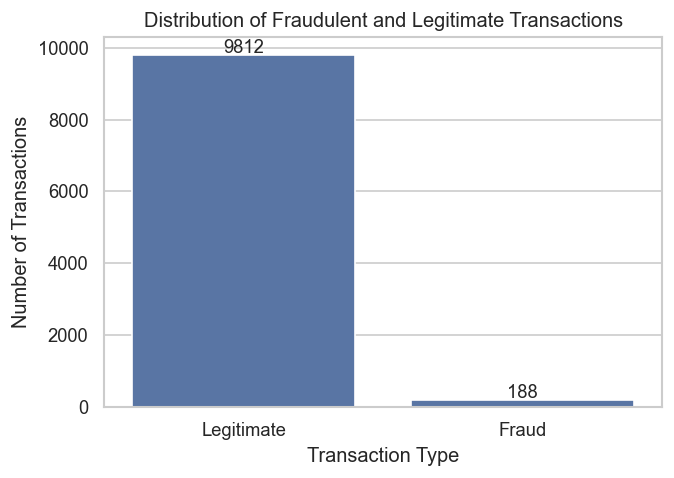

Percentage of transactions:
Is_fraud
0    98.12
1     1.88
Name: proportion, dtype: float64


In [18]:
fraud_counts = df["Is_fraud"].value_counts().sort_index()


plt.figure(figsize=(6, 4))

ax = sns.barplot(
    x=["Legitimate", "Fraud"],
    y=fraud_counts.values
)


for i, value in enumerate(fraud_counts.values):
    ax.text(i, value + 50, f"{value}", ha="center", fontsize=11)


plt.title("Distribution of Fraudulent and Legitimate Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()


fraud_percentage = (
    df["Is_fraud"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Percentage of transactions:")
print(fraud_percentage)

Transakcje fraudowe stanowią jedynie 1,88% wszystkich obserwacji, co wskazuje na silną nierównowagę klas (class imbalance). Należy uwzględnić ten fakt podczas budowy i oceny modeli uczenia maszynowego, ponieważ sama metryka accuracy (dokładność) może prowadzić do mylących wniosków. W przypadku niezbalansowanych danych bardziej odpowiednimi metrykami oceny są precision, recall oraz F1-score.

### Analiza kwoty transakcji

Celem tej części analizy jest porównanie kwot transakcji fraudowych i prawidłowych oraz sprawdzenie, czy wartość transakcji może stanowić cechę odróżniającą oba typy transakcji.

In [19]:
df.groupby("Is_fraud")["Bank_Amount"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Is_fraud,,,,,,,,
0,9812.0,97.92,97.65,0.00,28.32,67.90,135.24,817.24
1,188.0,88.64,85.54,0.02,27.52,61.92,118.06,463.90


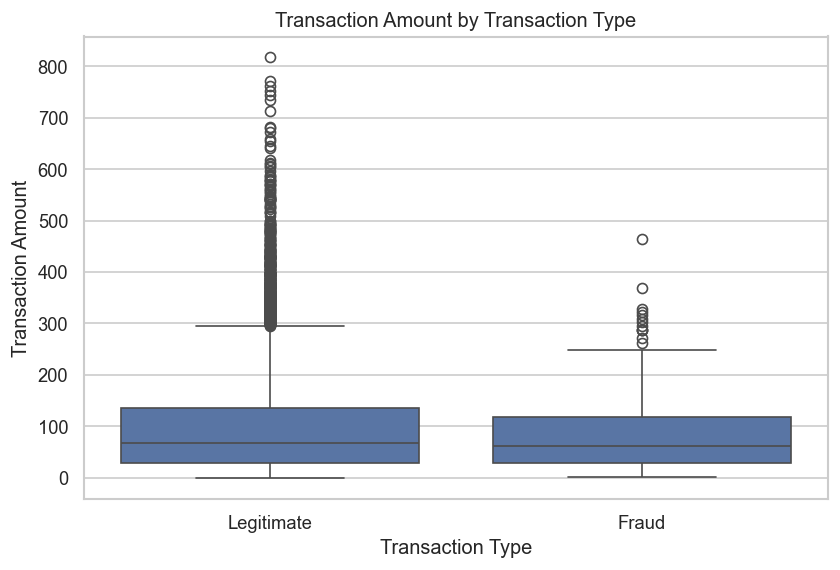

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Is_fraud",
    y="Bank_Amount"
)

plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.title("Transaction Amount by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Transaction Amount")

plt.show()

In [21]:
transaction_summary = (
    df.groupby("Is_fraud")["Bank_Amount"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

transaction_summary

,count,mean,median,std,min,max
Is_fraud,,,,,,
0,9812,97.92,67.90,97.65,0.00,817.24
1,188,88.64,61.92,85.54,0.02,463.90


W analizowanym zbiorze danych transakcje fraudowe charakteryzują się nieco niższymi kwotami niż transakcje prawidłowe. Różnica ta jest widoczna zarówno w średniej, jak i medianie wartości transakcji.

## Analiza czasu wykonania transakcji

Celem tej części analizy jest zbadanie, czy pora wykonania transakcji może mieć związek z występowaniem transakcji fraudowych.

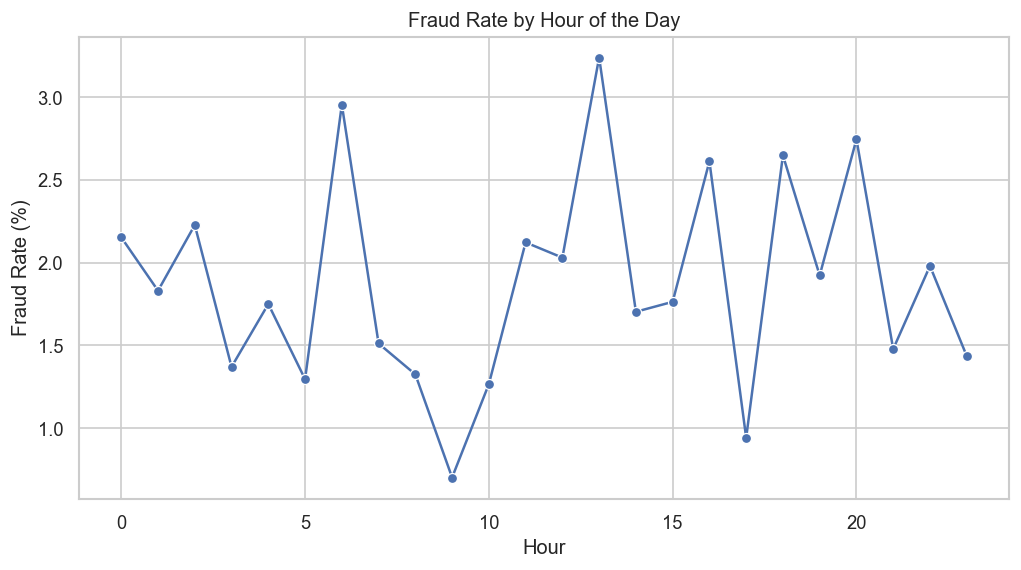

In [22]:
hourly_fraud_rate = (
    df.groupby("Hours")["Is_fraud"]
      .mean()
      .mul(100)
      .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hourly_fraud_rate,
    x="Hours",
    y="Is_fraud",
    marker="o"
)

plt.title("Fraud Rate by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")

plt.grid(True)

plt.show()

Analiza nie wykazała wyraźnej zależności pomiędzy godziną wykonania transakcji a występowaniem fraudów. Chociaż odsetek transakcji fraudowych nieznacznie różni się pomiędzy poszczególnymi godzinami, zaobserwowane różnice nie wskazują na jednoznaczny wzorzec czasowy. Oznacza to, że godzina wykonania transakcji prawdopodobnie nie stanowi samodzielnie istotnej cechy w wykrywaniu oszustw finansowych.

## Analiza typu urządzenia

Celem tej części analizy jest zbadanie, czy typ urządzenia użytego do wykonania transakcji może mieć związek z występowaniem transakcji fraudowych.

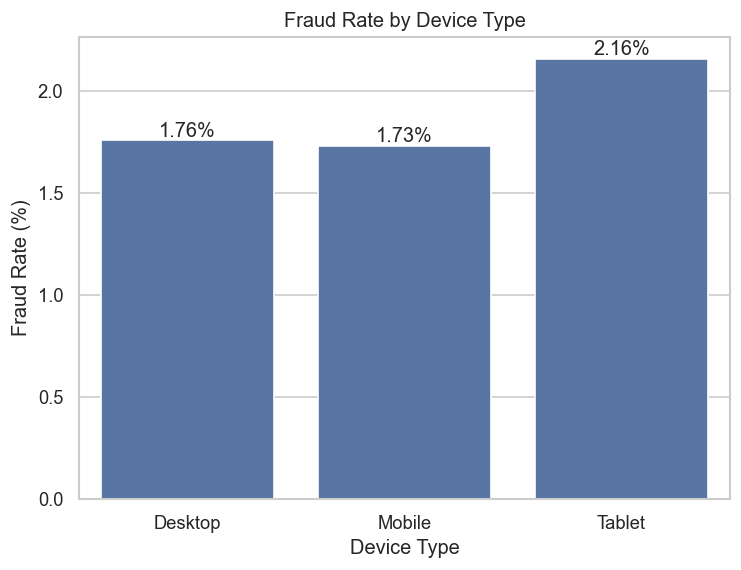

,Device,Fraud Rate (%)
0,Desktop,1.756955
1,Mobile,1.729894
2,Tablet,2.158055


In [23]:
device_fraud_rate = pd.DataFrame({
    "Device": ["Desktop", "Mobile", "Tablet"],
    "Fraud Rate (%)": [
        df.loc[df["device_type_desktop"], "Is_fraud"].mean() * 100,
        df.loc[df["Device_type_mobile"], "Is_fraud"].mean() * 100,
        df.loc[df["Device_type_tablet"], "Is_fraud"].mean() * 100,
    ]
})

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=device_fraud_rate,
    x="Device",
    y="Fraud Rate (%)"
)

for i, value in enumerate(device_fraud_rate["Fraud Rate (%)"]):
    ax.text(i, value + 0.02, f"{value:.2f}%", ha="center")

plt.title("Fraud Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Fraud Rate (%)")

plt.show()

device_fraud_rate

In [24]:
device_counts = pd.DataFrame({
    "Device": ["Desktop", "Mobile", "Tablet"],
    "Transactions": [
        df["device_type_desktop"].sum(),
        df["Device_type_mobile"].sum(),
        df["Device_type_tablet"].sum()
    ]
})

device_counts

,Device,Transactions
0,Desktop,3415
1,Mobile,3295
2,Tablet,3290


Analiza wykazała niewielkie różnice w odsetku transakcji fraudowych pomiędzy poszczególnymi typami urządzeń. Najwyższy odsetek fraudów odnotowano dla transakcji realizowanych z tabletów (2,16%), jednak zaobserwowane różnice są niewielkie. Na obecnym etapie można jedynie przypuszczać, że typ urządzenia może dostarczać dodatkowych informacji przy budowie modelu wykrywania fraudów. Potwierdzenie tej zależności wymaga przeprowadzenia analizy statystycznej.

##  Analiza kategorii transakcji

Celem tej części analizy jest zbadanie, czy kategoria transakcji może mieć związek z występowaniem transakcji fraudowych.

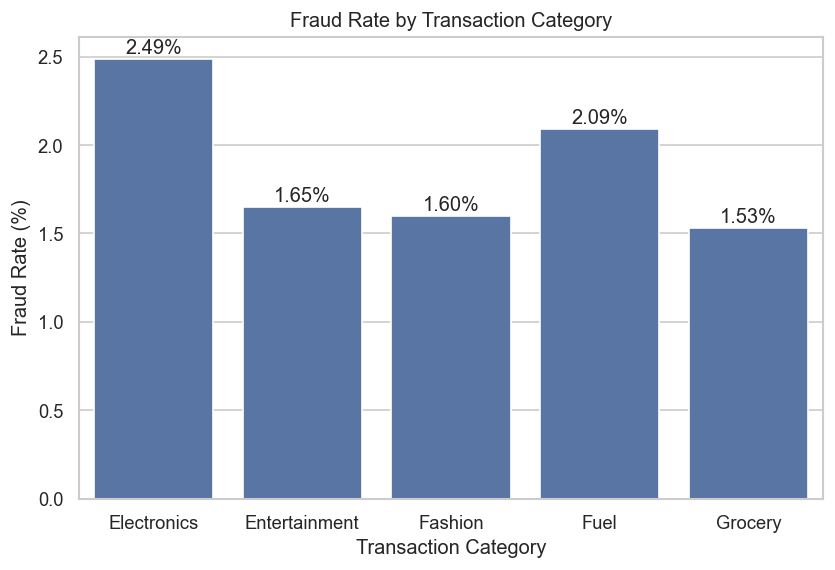

,Category,Fraud Rate (%)
0,Electronics,2.490421
1,Entertainment,1.648635
2,Fashion,1.597938
3,Fuel,2.092676
4,Grocery,1.531621


In [25]:
category_fraud_rate = pd.DataFrame({
    "Category": [
        "Electronics",
        "Entertainment",
        "Fashion",
        "Fuel",
        "Grocery"
    ],
    "Fraud Rate (%)": [
        df.loc[df["cat_electronics"], "Is_fraud"].mean() * 100,
        df.loc[df["cat_entertainment"], "Is_fraud"].mean() * 100,
        df.loc[df["cat_fashion"], "Is_fraud"].mean() * 100,
        df.loc[df["cat_fuel"], "Is_fraud"].mean() * 100,
        df.loc[df["cat_grocery"], "Is_fraud"].mean() * 100
    ]
})

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=category_fraud_rate,
    x="Category",
    y="Fraud Rate (%)"
)

for i, value in enumerate(category_fraud_rate["Fraud Rate (%)"]):
    ax.text(i, value + 0.03, f"{value:.2f}%", ha="center")

plt.title("Fraud Rate by Transaction Category")
plt.xlabel("Transaction Category")
plt.ylabel("Fraud Rate (%)")

plt.show()

category_fraud_rate

In [26]:
category_counts = pd.DataFrame({
    "Category": [
        "Electronics",
        "Entertainment",
        "Fashion",
        "Fuel",
        "Grocery"
    ],
    "Transactions": [
        df["cat_electronics"].sum(),
        df["cat_entertainment"].sum(),
        df["cat_fashion"].sum(),
        df["cat_fuel"].sum(),
        df["cat_grocery"].sum()
    ]
})

category_counts

,Category,Transactions
0,Electronics,2088
1,Entertainment,1941
2,Fashion,1940
3,Fuel,2007
4,Grocery,2024


Analiza wykazała zauważalne różnice w odsetku transakcji fraudowych pomiędzy poszczególnymi kategoriami transakcji. Najwyższy odsetek fraudów zaobserwowano w kategorii elektronika (2,49%), następnie paliwo (2,09%), natomiast najniższy w kategorii zakupy spożywcze (1,53%). Ponieważ każda z analizowanych kategorii obejmuje podobną liczbę transakcji, zaobserwowane różnice prawdopodobnie nie wynikają z nierównomiernej liczebności próby. Na obecnym etapie można przypuszczać, że kategoria transakcji może stanowić użyteczną cechę w modelach wykrywania fraudów. Potwierdzenie tej zależności wymaga jednak przeprowadzenia analizy statystycznej.

## Analiza lokalizacji klienta

Celem tej części analizy jest zbadanie, czy lokalizacja klienta może mieć związek z występowaniem transakcji fraudowych.

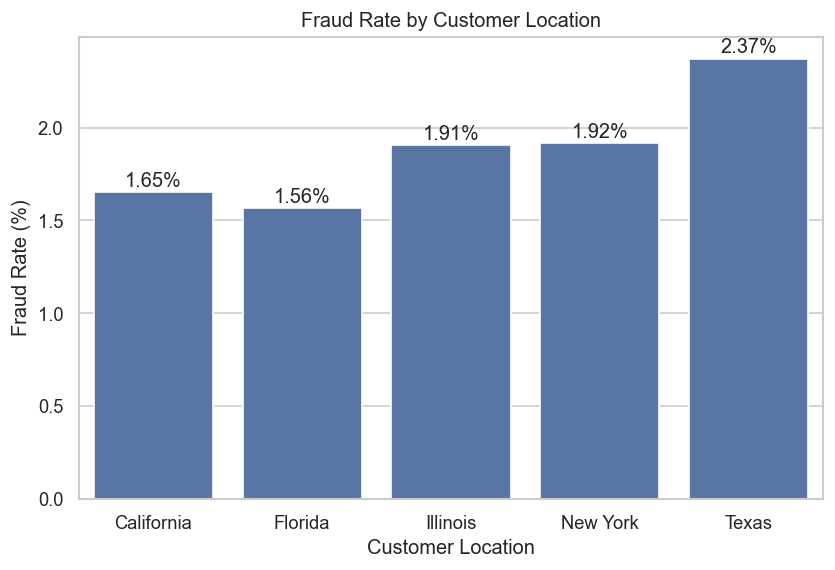

,Location,Fraud Rate (%)
0,California,1.652479
1,Florida,1.564027
2,Illinois,1.905717
3,New York,1.917255
4,Texas,2.372539


In [27]:
location_fraud_rate = pd.DataFrame({
    "Location": [
        "California",
        "Florida",
        "Illinois",
        "New York",
        "Texas"
    ],
    "Fraud Rate (%)": [
        df.loc[df["Cus_loc_CA"], "Is_fraud"].mean() * 100,
        df.loc[df["Cus_loc_FL"], "Is_fraud"].mean() * 100,
        df.loc[df["Cus_loc_IL"], "Is_fraud"].mean() * 100,
        df.loc[df["Cus_loc_NY"], "Is_fraud"].mean() * 100,
        df.loc[df["Cus_loc_TX"], "Is_fraud"].mean() * 100
    ]
})

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=location_fraud_rate,
    x="Location",
    y="Fraud Rate (%)"
)

for i, value in enumerate(location_fraud_rate["Fraud Rate (%)"]):
    ax.text(i, value + 0.03, f"{value:.2f}%", ha="center")

plt.title("Fraud Rate by Customer Location")
plt.xlabel("Customer Location")
plt.ylabel("Fraud Rate (%)")

plt.show()

location_fraud_rate

In [28]:

location_counts = pd.DataFrame({
    "Location": [
        "California",
        "Florida",
        "Illinois",
        "New York",
        "Texas"
    ],
    "Transactions": [
        df["Cus_loc_CA"].sum(),
        df["Cus_loc_FL"].sum(),
        df["Cus_loc_IL"].sum(),
        df["Cus_loc_NY"].sum(),
        df["Cus_loc_TX"].sum()
    ]
})

location_counts

,Location,Transactions
0,California,1997
1,Florida,2046
2,Illinois,1994
3,New York,1982
4,Texas,1981


Analiza wykazała umiarkowane różnice w odsetku transakcji fraudowych pomiędzy poszczególnymi lokalizacjami klientów. Najwyższy odsetek fraudów zaobserwowano w Teksasie (2,37%), natomiast najniższy na Florydzie (1,56%). Ponieważ każda z analizowanych lokalizacji obejmuje podobną liczbę transakcji, zaobserwowane różnice prawdopodobnie nie wynikają z nierównomiernej liczebności próby. Na obecnym etapie można przypuszczać, że lokalizacja klienta może stanowić użyteczną cechę w modelach wykrywania fraudów. Potwierdzenie tej zależności wymaga jednak przeprowadzenia analizy statystycznej.

## Analiza wieku klientów

Celem tej części analizy jest zbadanie, czy wiek klienta może mieć związek z występowaniem transakcji fraudowych.

In [29]:
age_summary = (
    df.groupby("Is_fraud")["Customer_age"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

age_summary

,count,mean,median,std,min,max
Is_fraud,,,,,,
0,9812,43.56,44.0,14.95,18,69
1,188,43.72,43.0,15.28,18,69


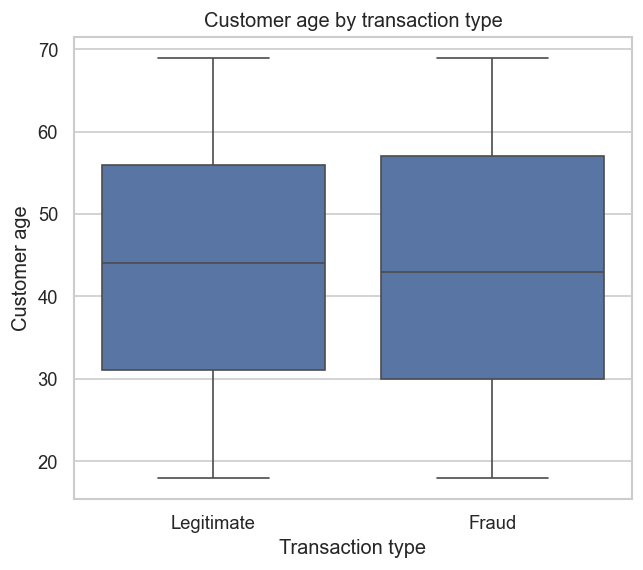

In [30]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="Is_fraud",
    y="Customer_age"
)

plt.xticks([0,1], ["Legitimate", "Fraud"])
plt.xlabel("Transaction type")
plt.ylabel("Customer age")
plt.title("Customer age by transaction type")

plt.show()

Statystyki opisowe wskazują, że rozkład wieku klientów jest bardzo podobny dla transakcji fraudowych i prawidłowych. Średnia, mediana oraz odchylenie standardowe osiągają zbliżone wartości w obu grupach, co sugeruje, że wiek klienta sam w sobie nie stanowi wyraźnego czynnika odróżniającego transakcje fraudowe od prawidłowych.

## 7. Analiza statystyczna

***Cel analizy***

Celem analizy statystycznej jest sprawdzenie, czy zależności zaobserwowane podczas eksploracyjnej analizy danych (EDA) są statystycznie istotne. W tym celu zostaną zweryfikowane hipotezy dotyczące związku pomiędzy wybranymi cechami transakcji a występowaniem fraudów z wykorzystaniem odpowiednich testów statystycznych.

### Hipoteza 1

Czy kwota transakcji różni się pomiędzy transakcjami fraudowymi i prawidłowymi?

Hipoteza zerowa (H₀):
Rozkład kwoty transakcji jest taki sam dla transakcji fraudowych i prawidłowych.

Hipoteza alternatywna (H₁):
Rozkład kwoty transakcji różni się pomiędzy transakcjami fraudowymi i prawidłowymi.

Na podstawie eksploracyjnej analizy danych stwierdzono, że rozkład kwoty transakcji jest prawostronnie skośny oraz zawiera wartości odstające. W związku z niespełnieniem założenia normalności oraz dużą nierównowagą liczebności grup do porównania kwot transakcji zastosowano nieparametryczny test U Manna–Whitneya.

In [31]:
from scipy.stats import mannwhitneyu

In [32]:
fraud = df[df["Is_fraud"] == 1]["Bank_Amount"]
non_fraud = df[df["Is_fraud"] == 0]["Bank_Amount"]

statistic, p_value = mannwhitneyu(
    fraud,
    non_fraud,
    alternative="two-sided"
)

print(f"U statistic: {statistic:.2f}")
print(f"p-value: {p_value:.6f}")

U statistic: 884352.00
p-value: 0.332778


In [33]:
alpha = 0.05

if p_value < alpha:
    print("Odrzucamy hipotezę zerową.")
    print("Istnieje statystycznie istotna różnica pomiędzy kwotami transakcji fraudowych i prawidłowych.")
else:
    print("Brak podstaw do odrzucenia hipotezy zerowej.")
    print("Nie stwierdzono statystycznie istotnej różnicy pomiędzy kwotami transakcji.")

Brak podstaw do odrzucenia hipotezy zerowej.
Nie stwierdzono statystycznie istotnej różnicy pomiędzy kwotami transakcji.


### Hipoteza 2

Czy typ urządzenia użytego do wykonania transakcji jest związany z występowaniem fraudów?

**Hipoteza zerowa (H₀):**
Typ urządzenia i występowanie fraudu są od siebie niezależne.

**Hipoteza alternatywna (H₁):**
Typ urządzenia i występowanie fraudu są od siebie zależne.

from scipy.stats import chi2_contingency

In [34]:
device = np.select(
    [
        df["device_type_desktop"],
        df["Device_type_mobile"],
        df["Device_type_tablet"]
    ],
    [
        "Desktop",
        "Mobile",
        "Tablet"
    ],
    default="Unknown"
)

device_df = pd.DataFrame({
    "Device": device,
    "Is_fraud": df["Is_fraud"]
})

contingency_table = pd.crosstab(
    device_df["Device"],
    device_df["Is_fraud"]
)

contingency_table

Is_fraud,0,1
Device,,
Desktop,3355,60
Mobile,3238,57
Tablet,3219,71


In [35]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")

NameError: name 'chi2_contingency' is not defined

In [36]:
expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

expected_df

NameError: name 'expected' is not defined

Założenia testu chi-kwadrat zostały spełnione, ponieważ oczekiwane liczebności we wszystkich komórkach tabeli były większe od 5. Wynik testu można uznać za wiarygodny.

### Hipoteza 3

Czy kategoria transakcji jest związana z występowaniem fraudów?

**Hipoteza zerowa (H₀):**
Kategoria transakcji i występowanie fraudu są od siebie niezależne.

**Hipoteza alternatywna (H₁):**
Kategoria transakcji i występowanie fraudu są od siebie zależne.

In [37]:

category = np.select(
    [
        df["cat_electronics"],
        df["cat_entertainment"],
        df["cat_fashion"],
        df["cat_fuel"],
        df["cat_grocery"]
    ],
    [
        "Electronics",
        "Entertainment",
        "Fashion",
        "Fuel",
        "Grocery"
    ],
    default="Unknown"
)

category_df = pd.DataFrame({
    "Category": category,
    "Is_fraud": df["Is_fraud"]
})

category_contingency_table = pd.crosstab(
    category_df["Category"],
    category_df["Is_fraud"]
)

category_contingency_table

Is_fraud,0,1
Category,,
Electronics,2036,52
Entertainment,1909,32
Fashion,1909,31
Fuel,1965,42
Grocery,1993,31


In [38]:
chi2, p_value, dof, expected = chi2_contingency(category_contingency_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")

NameError: name 'chi2_contingency' is not defined

In [39]:
expected_category_df = pd.DataFrame(
    expected,
    index=category_contingency_table.index,
    columns=category_contingency_table.columns
)

expected_category_df

NameError: name 'expected' is not defined

### Hipoteza 4

Czy lokalizacja klienta jest związana z występowaniem fraudów?

**Hipoteza zerowa (H₀):**
Lokalizacja klienta i występowanie fraudu są od siebie niezależne.

**Hipoteza alternatywna (H₁):**
Lokalizacja klienta i występowanie fraudu są od siebie zależne.

In [40]:
location = np.select(
    [
        df["Cus_loc_CA"],
        df["Cus_loc_FL"],
        df["Cus_loc_IL"],
        df["Cus_loc_NY"],
        df["Cus_loc_TX"]
    ],
    [
        "California",
        "Florida",
        "Illinois",
        "New York",
        "Texas"
    ],
    default="Unknown"
)

location_df = pd.DataFrame({
    "Location": location,
    "Is_fraud": df["Is_fraud"]
})

location_contingency_table = pd.crosstab(
    location_df["Location"],
    location_df["Is_fraud"]
)

location_contingency_table

Is_fraud,0,1
Location,,
California,1964,33
Florida,2014,32
Illinois,1956,38
New York,1944,38
Texas,1934,47


In [41]:
chi2, p_value, dof, expected = chi2_contingency(location_contingency_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")

NameError: name 'chi2_contingency' is not defined

In [42]:
expected_location_df = pd.DataFrame(
    expected,
    index=location_contingency_table.index,
    columns=location_contingency_table.columns
)

expected_location_df

NameError: name 'expected' is not defined

Na podstawie analizowanego zbioru danych nie stwierdzono statystycznie istotnej zależności pomiędzy lokalizacją klienta a występowaniem fraudów.

### Hipoteza 5

Czy wiek klienta różni się pomiędzy transakcjami fraudowymi i prawidłowymi?

Hipoteza zerowa (H₀):
Rozkład wieku klientów jest taki sam dla transakcji fraudowych i prawidłowych.

Hipoteza alternatywna (H₁):
Rozkład wieku klientów różni się pomiędzy transakcjami fraudowymi i prawidłowymi.

In [43]:
fraud_age = df[df["Is_fraud"] == 1]["Customer_age"]
non_fraud_age = df[df["Is_fraud"] == 0]["Customer_age"]

statistic, p_value = mannwhitneyu(
    fraud_age,
    non_fraud_age,
    alternative="two-sided"
)

print(f"U statistic: {statistic:.2f}")
print(f"P-value: {p_value:.6f}")

U statistic: 928072.00
P-value: 0.883518


In [44]:
alpha = 0.05

if p_value < alpha:
    print("Odrzuć H₀")
    print("Wiek klientów różni się statystycznie między grupami.")
else:
    print("Brak podstaw do odrzucenia hipotezy zerowej.")
    print("Nie stwierdzono statystycznie istotnej różnicy wieku klientów pomiędzy transakcjami fraudowymi i prawidłowymi.")

Brak podstaw do odrzucenia hipotezy zerowej.
Nie stwierdzono statystycznie istotnej różnicy wieku klientów pomiędzy transakcjami fraudowymi i prawidłowymi.


# 8. Wnioski po analizie

### Insight 1

Transakcje fraudowe stanowią jedynie 1,88% wszystkich obserwacji, co wskazuje na silną nierównowagę klas (class imbalance).

### Insight 2

W celu porównania kwot transakcji fraudowych i prawidłowych zastosowano test U Manna–Whitneya. Wynik testu nie wykazał statystycznie istotnych różnic pomiędzy analizowanymi grupami (U = 884352, p = 0,333). Oznacza to, że na podstawie dostępnych danych nie ma podstaw do stwierdzenia, iż kwota transakcji istotnie różni się pomiędzy transakcjami fraudowymi i prawidłowymi. W konsekwencji sama kwota transakcji prawdopodobnie nie stanowi silnej cechy umożliwiającej wykrywanie fraudów.


### Insight 3

Nie zaobserwowano wyraźnego wzorca czasowego w rozkładzie transakcji w poszczególnych godzinach dnia.

### Insight 4

W celu sprawdzenia, czy typ urządzenia jest związany z występowaniem transakcji fraudowych, zastosowano test niezależności chi-kwadrat. Wynik testu nie wykazał statystycznie istotnej zależności pomiędzy typem urządzenia a występowaniem fraudów (χ² = 2,062; p = 0,357). Oznacza to, że na podstawie analizowanego zbioru danych nie ma podstaw do stwierdzenia, że typ urządzenia wpływa na prawdopodobieństwo wystąpienia fraudu.

### Insight 5

W celu sprawdzenia, czy kategoria transakcji jest związana z występowaniem fraudów, zastosowano test niezależności chi-kwadrat. Założenia testu zostały spełnione, ponieważ oczekiwane liczebności we wszystkich komórkach tabeli przekraczały wartość 5. Wynik testu nie wykazał statystycznie istotnej zależności pomiędzy kategorią transakcji a występowaniem fraudów (χ² = 7,441; p = 0,114). Oznacza to, że na podstawie analizowanego zbioru danych nie ma podstaw do stwierdzenia, że kategoria transakcji ma istotny związek z występowaniem fraudów.

### Insight 6

W celu sprawdzenia, czy lokalizacja klienta jest związana z występowaniem transakcji fraudowych, zastosowano test niezależności chi-kwadrat. Założenia testu zostały spełnione, ponieważ oczekiwane liczebności we wszystkich komórkach tabeli przekraczały wartość 5. Wynik testu nie wykazał statystycznie istotnej zależności pomiędzy lokalizacją klienta a występowaniem fraudów (χ² = 4,295; p = 0,368). Oznacza to, że na podstawie analizowanego zbioru danych nie ma podstaw do stwierdzenia, że lokalizacja klienta ma istotny związek z występowaniem fraudów.

### Insight 7
W celu sprawdzenia, czy wiek klienta różni się pomiędzy transakcjami fraudowymi i prawidłowymi, zastosowano test U Manna–Whitneya. Wynik testu nie wykazał statystycznie istotnych różnic pomiędzy analizowanymi grupami (U = 928072; p = 0,884). Oznacza to, że na podstawie analizowanego zbioru danych nie ma podstaw do stwierdzenia, że wiek klienta ma związek z występowaniem transakcji fraudowych.

## Rekomendacje


Transakcje fraudowe stanowią jedynie 1,88% wszystkich obserwacji, co wskazuje na silną nierównowagę klas (class imbalance). Z tego względu podczas budowy i oceny modeli predykcyjnych należy zwrócić szczególną uwagę na dobór odpowiednich metryk oceny, takich jak precision, recall i F1-score, ponieważ sama metryka accuracy może prowadzić do mylących wniosków.

Ze względu na cel projektu kluczową metryką oceny modeli jest recall (czułość), ponieważ niewykrycie transakcji fraudowej może skutkować stratami finansowymi. Równocześnie istotna jest również precision (precyzja), pozwalająca ograniczyć liczbę fałszywych alarmów i uniknąć niepotrzebnego blokowania prawidłowych transakcji klientów. W związku z tym F1-score, będący harmoniczną średnią precision i recall, stanowi zrównoważoną metrykę oceny skuteczności modeli wykrywania fraudów.

***Eksploracyjna analiza danych wskazała na niewielkie różnice pomiędzy grupami, jednak przeprowadzone testy statystyczne nie potwierdziły ich istotności statystycznej. Oznacza to, że żadna z analizowanych cech rozpatrywana pojedynczo nie wykazuje istotnego związku z występowaniem fraudów. Nie wyklucza to jednak ich przydatności w modelach uczenia maszynowego, które jednocześnie analizują wiele cech i ich wzajemne zależności.***

## Modelowanie

Po przeprowadzeniu eksploracyjnej analizy danych oraz analizy statystycznej przystąpiono do budowy modelu klasyfikacyjnego. Celem modelu jest identyfikacja transakcji fraudowych na podstawie dostępnych cech opisujących transakcję.

Importy

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score
)

In [46]:
X = df.drop(
    columns=[
        "Transaction_id",
        "Customer_id",
        "Timestamp",
        "Is_fraud"
    ]
)

y = df["Is_fraud"]

Powyżej usuwam kolumny, które mogłyby zakłócić modelowanie. Transaction_id to losowy identyfikator, nie niesie informacji. Customer_id - model mógłby nauczyć się, że klient 123 = fraud, to przeuczenie. Timestamp już rozdzililiśmy, więc pełen nie jest potrzebny.

## Przygotowanie danych do modelowania

Po zakończeniu eksploracyjnej analizy danych oraz analizy statystycznej przygotowano dane do budowy modeli klasyfikacyjnych. W tym celu wydzielono zmienne objaśniające (X) oraz zmienną docelową (y), a następnie podzielono dane na zbiór treningowy i testowy.

Zastosowano podział danych w proporcji 80% zbiór treningowy i 20% zbiór testowy. Parametr `stratify=y` pozwala zachować taki sam udział transakcji fraudowych w obu zbiorach, co jest szczególnie istotne przy silnie niezbalansowanych klasach.

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(8000, 22)
(2000, 22)
Is_fraud
0    7850
1     150
Name: count, dtype: int64
Is_fraud
0    1962
1      38
Name: count, dtype: int64


## Random Forest

Random Forest to model zespołowy (ensemble), który składa się z wielu drzew decyzyjnych. Każde drzewo uczy się na losowej próbce danych oraz losowym podzbiorze cech, a końcowa predykcja jest wynikiem głosowania wszystkich drzew. Takie podejście zwykle zapewnia lepszą jakość predykcji i mniejsze ryzyko przeuczenia niż pojedyncze drzewo decyzyjne.

Random Forest został wykorzystany jako pierwszy model oparty na drzewach decyzyjnych. Model buduje wiele drzew decyzyjnych i łączy ich wyniki, co zwykle pozwala uzyskać lepszą skuteczność niż pojedyncze drzewo. Ze względu na niezbalansowane klasy zastosowano parametr `class_weight="balanced"`.

In [49]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

Model zbuduje 300 drzew decyzyjnych, większa wagę otrzymaja transakcje fraudowe, ponieważ jest ich znacznie mniej, random_state zapewnia powtarzalność wyników.

In [50]:
# Predict classes
y_pred = rf_model.predict(X_test)

# Predict probabilities
y_proba = rf_model.predict_proba(X_test)[:, 1]

### Ocena modelu Random Forest

Model oceniono na zbiorze testowym z wykorzystaniem metryk klasyfikacyjnych oraz wskaźników ROC AUC i PR AUC.

In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1962
           1       0.00      0.00      0.00        38

    accuracy                           0.98      2000
   macro avg       0.49      0.50      0.50      2000
weighted avg       0.96      0.98      0.97      2000



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [52]:
import pandas as pd

pd.Series(y_proba).describe()

count    2000.000000
mean        0.018317
std         0.014944
min         0.000000
25%         0.006667
50%         0.013333
75%         0.023333
max         0.123333
dtype: float64

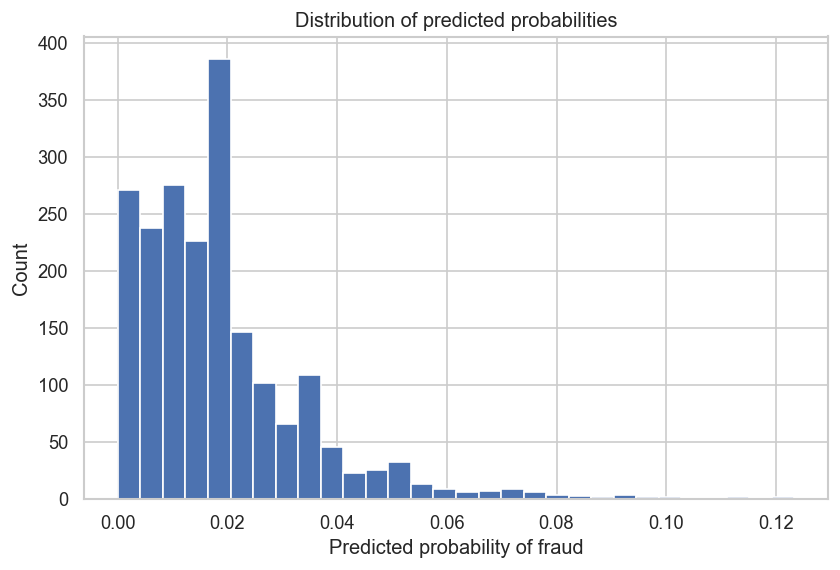

In [53]:
import matplotlib.pyplot as plt

plt.hist(y_proba, bins=30)
plt.xlabel("Predicted probability of fraud")
plt.ylabel("Count")
plt.title("Distribution of predicted probabilities")
plt.show()

In [54]:
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f"ROC AUC: {roc_auc:.3f}")
print(f"PR AUC: {pr_auc:.3f}")

ROC AUC: 0.411
PR AUC: 0.016


In [55]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Bank_Amount           10000 non-null  float64
 1   Customer_age          10000 non-null  int64  
 2   Previous_transaction  10000 non-null  int64  
 3   Month                 10000 non-null  int64  
 4   Day                   10000 non-null  int64  
 5   Week_day              10000 non-null  int64  
 6   Hours                 10000 non-null  int64  
 7   Minutes               10000 non-null  int64  
 8   Seconds               10000 non-null  int64  
 9   device_type_desktop   10000 non-null  bool   
 10  Device_type_mobile    10000 non-null  bool   
 11  Device_type_tablet    10000 non-null  bool   
 12  cat_electronics       10000 non-null  bool   
 13  cat_entertainment     10000 non-null  bool   
 14  cat_fashion           10000 non-null  bool   
 15  cat_fuel              10000 non

In [56]:
import numpy as np

np.unique(y_pred, return_counts=True)

(array([0]), array([2000]))

In [57]:
rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 300,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [58]:
import numpy as np

np.unique(y_pred, return_counts=True)

(array([0]), array([2000]))

Pomimo zastosowania class_weight='balanced' model Random Forest nie wykrył żadnej transakcji fraudowej w zbiorze testowym. W związku z tym zdecydowano się przetestować bardziej zaawansowany model XGBoost.

## XGBoost

XGBoost został wykorzystany jako bardziej zaawansowany model klasyfikacyjny. Model ten opiera się na metodzie gradient boosting, czyli budowaniu kolejnych drzew w taki sposób, aby poprawiały błędy popełnione przez wcześniejsze drzewa. XGBoost często dobrze sprawdza się w problemach klasyfikacji na danych tabelarycznych oraz pozwala uwzględnić nierównowagę klas.

Importy

In [59]:
from xgboost import XGBClassifier

In [60]:
negative_count = y_train.value_counts()[0]
positive_count = y_train.value_counts()[1]

scale_pos_weight = negative_count / positive_count

scale_pos_weight

np.float64(52.333333333333336)

***Pierwszy model XGBoost***

### Model bazowy XGBoost

Pierwszy model XGBoost został zbudowany z wykorzystaniem podstawowych hiperparametrów oraz parametru `scale_pos_weight`, który uwzględnia silną nierównowagę klas poprzez zwiększenie wagi obserwacji fraudowych podczas treningu.

In [61]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

Predykcje

In [62]:
# Predykcja klas
y_pred = xgb_model.predict(X_test)

# Predykcja prawdopodobieństwa klasy fraud
y_proba = xgb_model.predict_proba(X_test)[:, 1]

Classification report

In [63]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95      1962
           1       0.01      0.05      0.02        38

    accuracy                           0.90      2000
   macro avg       0.50      0.49      0.48      2000
weighted avg       0.96      0.90      0.93      2000



Confusion Matrix

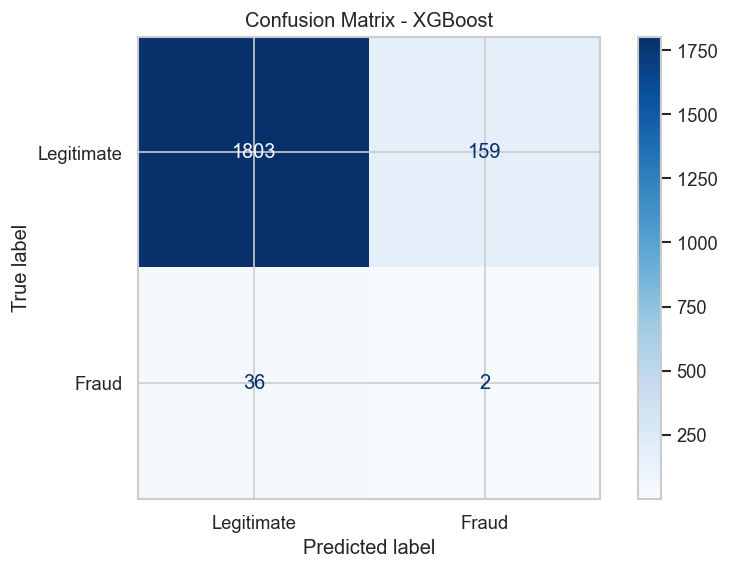

In [64]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.show()

ROC AUC i PR AUC

In [65]:
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f"ROC AUC: {roc_auc:.3f}")
print(f"PR AUC: {pr_auc:.3f}")

ROC AUC: 0.451
PR AUC: 0.017


In [66]:
import pandas as pd

predictions = pd.DataFrame({
    "true_label": y_test,
    "probability": y_proba
})

predictions.sort_values(
    by="probability",
    ascending=False
).head(20)

,true_label,probability
9706,0,0.865330
9129,0,0.831156
1,0,0.809247
7074,0,0.782679
9755,0,0.761209
1945,0,0.756558
8163,0,0.754093
4504,0,0.752399
4406,0,0.738740
7770,0,0.733576


In [67]:
print(df["Is_fraud"].value_counts())

Is_fraud
0    9812
1     188
Name: count, dtype: int64


In [68]:
print(df["Is_fraud"].dtype)

int64


## Oversampling – SMOTE

Ponieważ zbiór danych charakteryzuje się dużą nierównowagą klas, zastosowano metodę SMOTE (Synthetic Minority Over-sampling Technique). Algorytm generuje syntetyczne przykłady klasy mniejszości, dzięki czemu model uczy się na bardziej zrównoważonym zbiorze treningowym.

In [69]:
from imblearn.over_sampling import SMOTE

In [70]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [71]:
print(y_train.value_counts())

print()

print(y_train_smote.value_counts())

Is_fraud
0    7850
1     150
Name: count, dtype: int64

Is_fraud
0    7850
1    7850
Name: count, dtype: int64


Teraz nie używamy już scale_pos_weight. Po SMOTE klasy są już zbalansowane. Gdybyśmy zostawili jeszcze scale_pos_weight=52, to klasa fraud byłaby "uprzywilejowana" podwójnie.

In [72]:
xgb_model_smote = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model_smote.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

Czy SMOTE zadziałał?

In [73]:
print(y_train.value_counts())

print()

print(y_train_smote.value_counts())

Is_fraud
0    7850
1     150
Name: count, dtype: int64

Is_fraud
0    7850
1    7850
Name: count, dtype: int64


In [74]:
y_pred_smote = xgb_model_smote.predict(X_test)
y_proba_smote = xgb_model_smote.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1962
           1       0.00      0.00      0.00        38

    accuracy                           0.98      2000
   macro avg       0.49      0.50      0.50      2000
weighted avg       0.96      0.98      0.97      2000



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [75]:
roc_auc_smote = roc_auc_score(y_test, y_proba_smote)
pr_auc_smote = average_precision_score(y_test, y_proba_smote)

print(f"ROC AUC: {roc_auc_smote:.3f}")
print(f"PR AUC: {pr_auc_smote:.3f}")

ROC AUC: 0.495
PR AUC: 0.019


In [76]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance


,Feature,Importance
13,cat_entertainment,0.080246
21,Cus_loc_TX,0.055050
16,cat_grocery,0.052536
4,Day,0.052416
19,Cus_loc_IL,0.049210
3,Month,0.048013
15,cat_fuel,0.047783
8,Seconds,0.047120
0,Bank_Amount,0.046924
2,Previous_transaction,0.046507


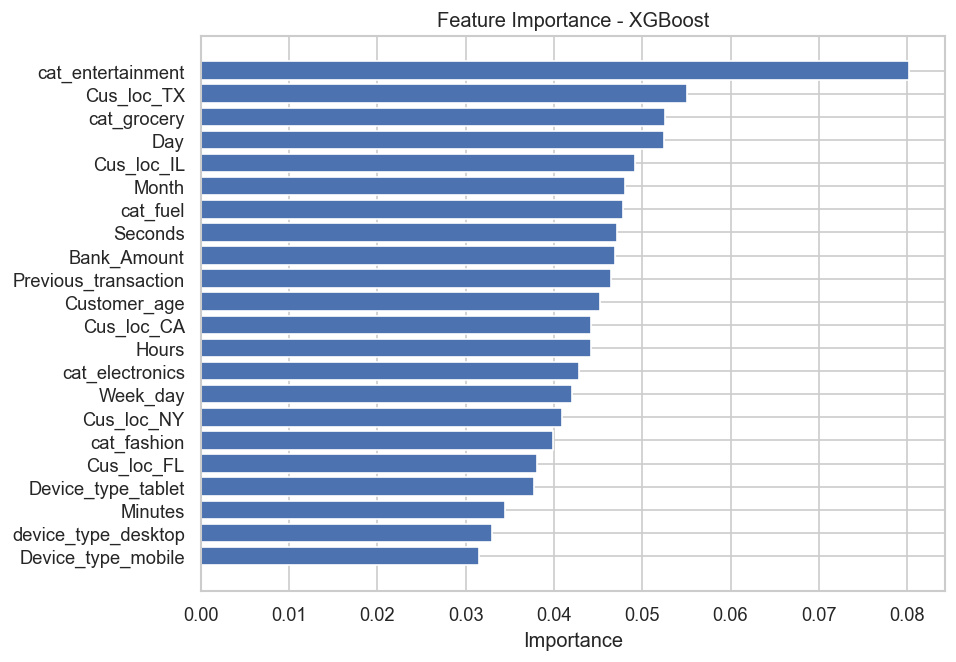

In [77]:
plt.figure(figsize=(8,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Feature Importance - XGBoost")

plt.gca().invert_yaxis()

plt.show()

## Undersampling

Undersampling polega na losowym zmniejszeniu liczby obserwacji klasy większości do poziomu klasy mniejszości. Dzięki temu model uczy się na zbalansowanym zbiorze danych, jednak kosztem utraty części informacji zawartych w transakcjach prawidłowych.

In [78]:
from imblearn.under_sampling import RandomUnderSampler

In [79]:
undersampler = RandomUnderSampler(
    random_state=42
)

X_train_under, y_train_under = undersampler.fit_resample(
    X_train,
    y_train
)

In [80]:
print(y_train_under.value_counts())

Is_fraud
0    150
1    150
Name: count, dtype: int64


In [81]:
xgb_under = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_under.fit(
    X_train_under,
    y_train_under
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

Po zastosowaniu undersamplingu ponownie wytrenowano model XGBoost, aby porównać wpływ różnych metod radzenia sobie z niezbalansowanymi klasami na skuteczność wykrywania fraudów.

In [82]:
y_pred_under = xgb_under.predict(X_test)
y_proba_under = xgb_under.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_under))

roc_auc_under = roc_auc_score(y_test, y_proba_under)
pr_auc_under = average_precision_score(y_test, y_proba_under)

print(f"ROC AUC: {roc_auc_under:.3f}")
print(f"PR AUC: {pr_auc_under:.3f}")

              precision    recall  f1-score   support

           0       0.98      0.48      0.64      1962
           1       0.02      0.53      0.04        38

    accuracy                           0.48      2000
   macro avg       0.50      0.50      0.34      2000
weighted avg       0.96      0.48      0.63      2000

ROC AUC: 0.505
PR AUC: 0.020


***Model, po undersamplingu wykrywa więcej fraudów, ale jednocześnie oznacza ogromną liczbę legalnych transakcji jako fraud.***

## Wnioski

Zastosowano kilka metod radzenia sobie z niezbalansowanymi klasami, w tym ważenie klas (scale_pos_weight), oversampling (SMOTE) oraz undersampling. Chociaż undersampling zwiększył czułość modelu (recall), odbyło się to kosztem bardzo dużej liczby fałszywych alarmów (false positives). Jednocześnie wartości ROC AUC i PR AUC pozostały bliskie poziomowi losowemu, co sugeruje, że dostępne cechy nie zawierają wystarczającej informacji do skutecznego rozróżnienia transakcji fraudowych od legalnych.

# Podsumowanie modeli

W ramach projektu porównano kilka podejść do wykrywania transakcji fraudowych:

- Logistic Regression – model bazowy.
- Decision Tree – pojedyncze drzewo decyzyjne.
- Random Forest – z wykorzystaniem ważenia klas (`class_weight`).
- XGBoost – z wykorzystaniem `scale_pos_weight`.
- XGBoost + SMOTE – oversampling klasy mniejszości.
- XGBoost + Random UnderSampling – redukcja klasy większości.

Porównanie wyników pokazało, że zastosowanie różnych modeli oraz metod balansowania klas nie doprowadziło do znaczącej poprawy jakości klasyfikacji. Uzyskane wyniki sugerują, że dostępne cechy zawierają ograniczoną ilość informacji umożliwiających skuteczne rozróżnienie transakcji fraudowych od legalnych.